In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from scipy.stats import poisson


First time stamp is  803
Last time stamp is  24609058


<Figure size 400x400 with 0 Axes>

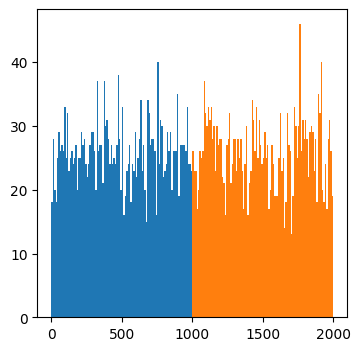

In [6]:

fname = "FileC017.txt"
df = pd.read_csv(fname,skiprows=7,sep='\\s+',names = ['Event', 'Time', 'Date', 'TimeStamp', 'ADC1', 'ADC2', 'SiPM', 'Temp', 'Pressure', 'DeadTime', 'Coincident', 'ID'])
event = df["Event"].array
timestamp = df["TimeStamp"].array

t1 = 0
t2 = 1000
print("First time stamp is ", timestamp[0])
print("Last time stamp is ",timestamp[-1])
plt.figure(figsize = (4,4))

# counts, e1,e2, xxx = plt.hist2d(event[0:10000],timestamp[0:10000],bins=(100,100),cmin=0.1)
# plt.ylabel("Timestamp [ms]")
# plt.xlabel("Event number")
# plt.show()
#make histogram with 100 10s bins

plt.figure(figsize = (4,4))
counts, e2, xxx = plt.hist(timestamp/1000,range=(0,1000),bins=100)
counts2, e3, xxx = plt.hist(timestamp/1000,range=(1000,2000),bins=100)

In [7]:
counts_running_avg = np.cumsum(counts) / np.arange(1, len(counts) + 1)
counts_running_avg_2 = np.cumsum(counts2) / np.arange(1, len(counts2) + 1)

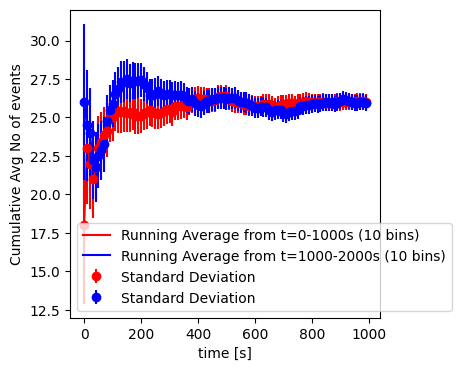

In [8]:
# Plot the running average
plt.figure(figsize = (4,4))
plt.plot(e2[:-1], counts_running_avg, label='Running Average from t=0-1000s (10 bins)', color='red')
plt.plot(e3[:-1]-1000, counts_running_avg_2, label='Running Average from t=1000-2000s (10 bins)', color='blue')

# add error bars to the running average plot where each error bar is the standard deviation of the counts in the corresponding bin
bin_stderr = np.sqrt(counts_running_avg[-1])/np.sqrt(np.arange(1, len(counts_running_avg)+1))  # Standard error for Poisson distribution
bin_stderr_2 = np.sqrt(counts_running_avg_2[-1])/np.sqrt(np.arange(1, len(counts_running_avg_2)+1))  # Standard error for Poisson distribution
# plot the error bars
plt.errorbar(e2[:-1], counts_running_avg, yerr=bin_stderr, fmt='o', color='red', label='Standard Deviation')
plt.errorbar(e3[:-1] - 1000, counts_running_avg_2, yerr=bin_stderr_2, fmt='o', color='blue', label='Standard Deviation')

plt.xlabel("time [s]")
plt.ylabel("Cumulative Avg No of events")
plt.legend()
plt.show()

In [11]:

#find the p value for the null hypothesis that the two count rates are the same using the z test
mean1 = counts_running_avg[-1]
mean2 = counts_running_avg_2[-1]
std1 = np.sqrt(mean1 / len(counts_running_avg))
std2 = np.sqrt(mean2 / len(counts_running_avg_2))
z = (mean1 - mean2) / np.sqrt(std1**2 + std2**2)
p_value = 2 * (1 - norm.cdf(abs(z)))  # Two-tailed test

#print the means and ffinal errors

print("Mean count rate from t=0-1000s:", mean1)
print("Mean count rate from t=1000-2000s:", mean2)

print("Standard error of count rate from t=0-1000s:", std1)
print("Standard error of count rate from t=1000-2000s:", std2)

print("Z-score:", z)
print("P-value:", p_value)


Mean count rate from t=0-1000s: 26.02
Mean count rate from t=1000-2000s: 25.94
Standard error of count rate from t=0-1000s: 0.510098029794274
Standard error of count rate from t=1000-2000s: 0.5093132631298738
Z-score: 0.11098273312357022
P-value: 0.9116300391078824


[15 17 19 21 23 25 27 29 31 33 35 37 39]


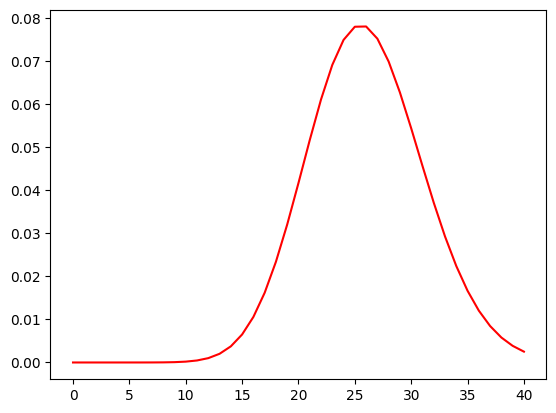

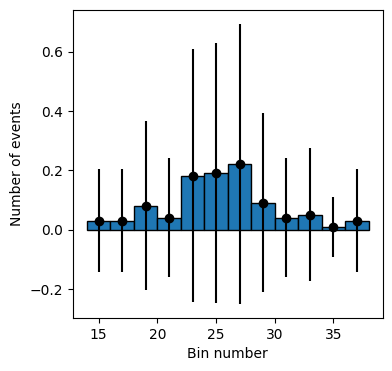

In [28]:
freq, bins = np.histogram(counts, bins=range(int(min(counts)), int(max(counts))+1, 2))


normalized_freq = freq / sum(freq)

poisson_mean = mean1
poisson_pmf = poisson.pmf(np.arange(0, max(counts)+1), poisson_mean)


#plot the poisson distribution as a line plot
plt.plot(np.arange(0, max(counts)+1), poisson_pmf, label='Poisson PMF', color='red')


#plot the histogram of the counts using a bar plot
print(bins)
plt.figure(figsize = (4,4))
plt.bar((bins[:-1]), normalized_freq, width=np.diff(bins), edgecolor='black')

#plot error bars as sqrt of counts
plt.errorbar((bins[:-1]), normalized_freq, yerr=np.sqrt(normalized_freq), fmt='o', color='black')

plt.xlabel("Bin number")
plt.ylabel("Number of events")
plt.show()


